In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
import de_test

In [3]:
import decoupler as dc

In [4]:
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()

ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [5]:
impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

In [6]:
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

In [7]:
#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    adata_raw,
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

Bas/MC prog


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2025-06-14 21:23:15,931] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (10,626) and rank = 1.0.
[2025-06-14 21:23:15,932] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-14 21:23:17,339] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono/DC prog
[2025-06-14 21:23:21,287] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (14,157) and rank = 1.0.
[2025-06-14 21:23:21,288] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-14 21:23:22,140] [INFO    ] Sigma interpreted as element-wise standard deviation.
Neu
[2025-06-14 21:23:27,573] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (23,442) and rank = 1.0.
[2025-06-14 21:23:27,575] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-14 21:23:28,761] [INFO    ] Sigma interpreted as element-wise standard deviation.
Ly
[2025-06-14 21:23:33,733] [INFO    ] Using sparse Gaussian Process since n_landm

In [235]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = adata_raw[adata_raw.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime
    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, 21)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=20,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.3  0.62 0.25 0.39 0.35 0.48 0.21 0.44 0.16 0.53 0.58 0.76 0.71 0.85
 0.67 0.9  0.81 0.12 0.07 0.02]
[0.39 0.34 0.31 0.37 0.28 0.42 0.45 0.47 0.26 0.53 0.5  0.23 0.18 0.15
 0.2  0.09 0.12 0.07 0.04 0.01]
[0.24 0.29 0.59 0.2  0.55 0.37 0.33 0.64 0.42 0.51 0.46 0.15 0.68 0.73
 0.81 0.77 0.86 0.11 0.07 0.02]


In [237]:
def find_steepest_region(x_values, rate_values,  min_bins=10):
    """
    Identify the pseudotime region with steepest slope
    
    Parameters:
    x_values: dict with pseudotime bins per lineage
    rate_values: dict with rate values (v or g) per lineage
    day_idx : int, the index to select which day of the paramter to use
    min_bins: minimum number of consecutive bins to consider
    
    Returns: dict with steepest region info per lineage
    """
    steepest_regions = {}
    

    # Calculate slopes using central differences
    dx = np.diff(x_values)[0]  # Assuming uniform spacing
    slopes = np.gradient(rate_values, dx)
    
    # Calculate absolute slopes for windowed analysis
    window_size = min_bins
    mean_abs_slopes = np.array([
        np.mean(np.abs(slopes[i:i+window_size]))
        for i in range(len(slopes) - window_size + 1)
    ])
    
    # Find window with maximum mean absolute slope
    max_idx = np.argmax(mean_abs_slopes)
    start_bin = x_values[max_idx]
    end_bin = x_values[max_idx + window_size - 1]
    
    steepest_regions = {
        'start_bin': start_bin,
        'end_bin': end_bin,
        'mean_slope': mean_abs_slopes[max_idx],
        'window_idx': (max_idx, max_idx + window_size)
    }
    
    return steepest_regions

def find_steepest_region(x_values, rate_values, day_idx, min_bins=10):
    """
    Identify the pseudotime region with steepest slope
    
    Parameters:
    x_values: dict with pseudotime bins per lineage
    rate_values: dict with rate values (v or g) per lineage
    day_idx : int, the index to select which day of the paramter to use
    min_bins: minimum number of consecutive bins to consider
    
    Returns: dict with steepest region info per lineage
    """
    steepest_regions = {}
    
    for lineage in x_values.keys():
        # Calculate slopes using central differences
        dx = np.diff(x_values[lineage])[0]  # Assuming uniform spacing
        slopes = np.gradient(rate_values[lineage][day_idx], dx)
        
        # Calculate absolute slopes for windowed analysis
        window_size = min_bins
        mean_abs_slopes = np.array([
            np.mean(np.abs(slopes[i:i+window_size]))
            for i in range(len(slopes) - window_size + 1)
        ])
        
        # Find window with maximum mean absolute slope
        max_idx = np.argmax(mean_abs_slopes)
        start_bin = x_values[lineage][max_idx]
        end_bin = x_values[lineage][max_idx + window_size - 1]
        
        steepest_regions[lineage] = {
            'start_bin': start_bin,
            'end_bin': end_bin,
            'mean_slope': mean_abs_slopes[max_idx],
            'window_idx': (max_idx, max_idx + window_size)
        }
    
    return steepest_regions

In [11]:
np.gradient(v_project['Neu'][7], np.diff(x_project["Neu"])[0]).shape

(99,)

In [12]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from de_test import fitGAM, run_fitGAM_parallel

In [13]:
def get_input(adata_lin, lineage):
    """
    prepare input for fitGAM
    """
    ad = adata_lin[lineage]
    cell_time = ad.obs["palantir_pseudotime"].values
    if 'MAGIC_imputed_data' in ad.layers:
        expression_matrix = ad.layers['MAGIC_imputed_data'].A.copy()
    else:
        expression_matrix = ad.X.A.copy()
    
    genes = ad.var_names.values
    
    return expression_matrix, cell_time, genes

In [ ]:
for lineage in ['Ery', 'Meg', 'Neu']:
    expression_matrix, cell_time, genes = get_input(adata_lin, lineage)

    # Run parallel GAM fitting
    # it takes around 7 minutes
    gam_fit2 = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
    de_test.save_gamfit(gam_fit2, save_dir=f'results/tompos_{lineage}_GAM/')

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


# new Associtation Test

In [14]:
from importlib import reload
reload(de_test)

<module 'de_test' from '/ssd/users/Wergillius/Project/PINN_dynamics/de_test/__init__.py'>

# select genes 

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from statsmodels.stats.multitest import multipletests

def select_top_de_genes(results_df, qval_threshold=0.05):
    """
    Select top differentially expressed genes based on p-value threshold
    
    Parameters:
    results_df: DataFrame with association test results
    qval_threshold: p-value threshold for selecting DE genes
    
    Returns: list of gene indices passing threshold
    """
    # Filter significant genes
    significant = results_df[~results_df['pvalue'].isna()]
    significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]
    
    # Sort by Wald statistic
    significant = significant.query("`fdr` <= @qval_threshold").sort_values('waldStat', ascending=False)
    
    return significant

def prepare_expression_data(gam_fit, pseudotime=None):
    """
    Prepare and scale gene expression data for plotting
    
    Parameters:
    gam_fit: fitted GAM models
    pseudotime: optional custom pseudotime points
    
    Returns: DataFrame with scaled expression values
    """
    if pseudotime is None:
        # Create prediction grid
        pseudotime = gam_fit['pseudotime']
        pred_grid = np.linspace(pseudotime.min(), pseudotime.max(), 100)
        pseudotime = pred_grid
    
    
    # Process each gene
    scaler = MinMaxScaler()
    
    Expr_list = []
    gene_symbol = []
    for i, gene_idx in enumerate(gam_fit['gene_names']):
        model_info = gam_fit['models'][gene_idx]
        
        # Get prediction function
        if model_info['model']:
            pred = model_info['pred_func'](pseudotime)
            scaled_pred = scaler.fit_transform(pred.reshape(-1, 1)).flatten()
            Expr_list.append(scaled_pred)
            gene_symbol.append(gam_fit['gene_symbol'][i])
        else:
            continue
            
        # Get predictions
        
        # Initialize DataFrame
        expr_df = pd.DataFrame(np.stack(Expr_list).T, columns=gene_symbol)
        expr_df.index = pseudotime
        # Scale and add to DataFrame
        # expr_df[f'gene_{gene_idx}'] = scaler.fit_transform(predictions.reshape(-1, 1)).flatten()
    
    return expr_df

In [16]:
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression

def calculate_mutual_information(
    parameter: np.ndarray,
    predicted_expression: np.ndarray,
    n_neighbors: int = 3,
    random_state: int = 42
) -> float:
    """
    Calculate mutual information between a parameter and predicted expression.
    
    Parameters:
        parameter (np.ndarray): Parameter values (e.g., pseudotime)
        predicted_expression (np.ndarray): Predicted expression values from GAM model
        n_neighbors (int): Number of neighbors to use for MI estimation
        random_state (int): Random state for reproducibility
        
    Returns:
        float: Mutual information value
    """
    # Ensure proper shape
    if parameter.ndim == 1:
        parameter = parameter.reshape(-1, 1)
        
    # Calculate mutual information
    mi = mutual_info_regression(
        parameter,
        predicted_expression,
        n_neighbors=n_neighbors,
        random_state=random_state
    )
    
    return float(mi[0])

In [17]:
mmTF = pd.read_csv("data/mouse_geneset/allTFs_mm.txt", sep='\t',  names=['gene_symbol'])

steepest_region_Day3 = find_steepest_region(x_project, v_project, 0)
steepest_region_Day7 = find_steepest_region(x_project, v_project, 1)
steepest_region_Day161 = find_steepest_region(x_project, v_project, 7)

In [ ]:


for lineage in ['Neu', 'Meg', 'Ery']:

    print(f"\nprocessing {lineage}")
    print("loading GAM model")
    
    gam_fit = de_test.load_gamfit(f'results/tompos_{lineage}_GAM/')
    
    print("preparing and scaling gene trends")
    lineage_expr_df = prepare_expression_data(gam_fit, pseudotime=x_project[lineage])
    lineage_expr_df.to_csv(f"results/tompos_{lineage}_GAM/GAM_scaled_expression.csv", index=True)

    # lineage_expr_df = lineage_expr_df.iloc[3:-3]

    for day_id in [0, 1, 7]:

        day = adata_raw.uns['pop']['t'][day_id]
        print(f"== processing Day {day} ==")

        steepest_region = find_steepest_region(x_project, v_project, day_id)
        pseudotime_range = (steepest_region[lineage]['start_bin'], 
                        steepest_region[lineage]['end_bin'])

        # # Run association tests
        test = de_test.AssociationTest(gam_fit, ['lineage'])
        result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
        result_lin_day['gene_symbol'] = gam_fit['gene_symbol']

        result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

        # select significantly DE genes and annotate TF
        significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
        significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
        significant_genes.set_index("gene_symbol", inplace=True)

        # compute parameter derivative
        dx = x_project[lineage][0]
        drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

        # compute correlation and mutual information
        corr_list = [pearsonr(lineage_expr_df.loc[:,gene].values[3:-3], drift_derivatives[3:-3])[0] for gene in significant_genes.index]
        mi_list = [calculate_mutual_information(lineage_expr_df.loc[:,gene].values[3:-3], drift_derivatives[3:-3]) for gene in significant_genes.index]

        significant_genes['pearson_r'] = corr_list
        significant_genes['mutual_information'] = mi_list

        significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

# Neu

In [210]:
significant_genes

<function __main__.significant_genes(corr_df, alpha=0.05)>

In [ ]:
sig_TFs = significant_genes.query("`meanLogFC`>1 & `mutual_information`>0.7 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
s = significant_genes.query("`meanLogFC`>2 & `pearson_r` > 0" ).sort_values("mutual_information", ascending=False)

In [239]:
sig_TFs

,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,mutual_information,pearson_r
gene_symbol,,,,,,,,,
Cebpe,13063,[16.1270949727634],1.0,[5.9230553683830007e-05],11.006933,[0.00013215008234569885],True,0.941470,0.137798
Cebpd,19226,[25.384447096087325],1.0,[4.696896782378788e-07],1.436561,[1.589954746306553e-06],True,0.856994,0.069550
Zbtb20,19540,[220.8311419067468],1.0,[5.957881585403794e-50],1.036081,[2.9709205674907767e-47],True,0.854837,-0.363565
Nfat5,12351,[151.94983604298648],1.0,[6.498149601733401e-35],1.111460,[1.3372779299440246e-32],True,0.854518,-0.278537
Mybl2,2732,[14.850329255002082],1.0,[0.00011638775080852906],1.466264,[0.00024628157160642717],True,0.837475,-0.050682
Pbx1,1046,[226.9568634840232],1.0,[2.7480128509832735e-51],1.155384,[1.9793325896110076e-48],True,0.835108,-0.340558
Zfpm1,12481,[191.51797816559565],1.0,[1.4825042881943085e-43],1.101377,[5.339074471233114e-41],True,0.833444,-0.330240
Cers4,11527,[116.67845531298337],1.0,[3.375938297177743e-27],1.112105,[2.620900600174218e-25],True,0.800909,-0.263436
Hlf,15735,[309.28417565432676],1.0,[3.127251280794427e-69],1.035839,[5.792116122214249e-66],True,0.768373,-0.449866


In [248]:
sig_genes

,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,mutual_information,pearson_r
gene_symbol,,,,,,,,,
Ncf1,7081,[44.3024914150519],1.0,[2.8135791468580966e-11],2.175425,[2.314467606346222e-10],False,1.075023,0.032161
Atp8b4,2343,[38.70739802111224],1.0,[4.923394584615117e-10],2.389891,[3.0911288517934623e-09],False,1.064184,0.221504
Clec12a,8492,[81.42850558123826],1.0,[1.8171788457247028e-19],2.241815,[5.088493247261506e-18],False,1.047599,0.377240
Cst7,2538,[42.75508067911869],1.0,[6.204054000002524e-11],2.958858,[4.72316853259147e-10],False,0.999289,0.437043
Slpi,2760,[30.248263664538722],1.0,[3.801314003078894e-08],5.617023,[1.612697514722443e-07],False,0.997941,0.255593
Hdc,2346,[21.223616060162232],1.0,[4.086975718676448e-06],6.165893,[1.1375071565859618e-05],False,0.977508,0.147131
Rab44,20189,[73.63327853213535],1.0,[9.406534225213441e-18],2.125368,[2.1661761319696671e-16],False,0.959305,0.138305
Cebpe,13063,[16.1270949727634],1.0,[5.9230553683830007e-05],11.006933,[0.00013215008234569885],True,0.941470,0.137798
Anxa3,6612,[50.77727132237563],1.0,[1.034649303098362e-12],4.262828,[1.1225295577129928e-11],False,0.895522,0.201193


# visualization

In [151]:
from itertools import cycle
import seaborn as sns
import matplotlib.pyplot as plt

def plot_de_genes_with_rate(
    expr_df, 
    steepest_region, 
    lineage='Neu', 
    day_idx=0,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,    # Assuming this is available from notebook
    ax=None
    ):
    """
    Plot scaled expression of DE genes with rate information
    
    Parameters:
    ------
    expr_df: DataFrame with scaled expression data
    steepest_region: dict with steepest region info
    lineage: cell lineage to plot
    day_idx: index of timepoint to show rate
    ax: optional matplotlib axes to plot on
    
    Returns: 
    ------
    matplotlib axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    
    # Create color and line style combinations
    colors = sns.color_palette()  # Get current Seaborn color palette
    linestyles = ['-', '--', '-.', ':']  # Available line styles
    
    # Create all possible combinations of color and line style
    style_cycle = cycle([(color, linestyle) for linestyle in linestyles for color in colors ])
    
    # Plot gene expression profiles
    genes = expr_df.columns.to_list()
    expr_dpt = expr_df.index.to_numpy()
    
    # Store legend elements
    legend_elements = []
    
    for col in genes:
        color, linestyle = next(style_cycle)
        line = ax.plot(
            expr_dpt,
            expr_df[col],
            color=color,
            linestyle=linestyle,
            alpha=0.7,
            label=f'{col.split("_")[-1]}'
        )
        # Add to legend elements
        legend_elements.append(plt.Line2D([0], [0], color=color, linestyle=linestyle, label=f'{col.split("_")[-1]}'))
    
    # Add rate information on secondary axis
    ax2 = ax.twinx()
    
    # Get rate data
    rate_values = v_project[lineage][day_idx]
    rate_pseudotime = x_project[lineage]

    mask = np.logical_and(rate_pseudotime<=expr_dpt.max(), rate_pseudotime>=expr_dpt.min())
    
    # Plot rate
    rate_line = ax2.plot(
        rate_pseudotime[mask],
        rate_values[mask],
        color='navy',
        linewidth=2,
        linestyle='--',
        label=f'Rate (Day {day_idx})'
    )
    
    # Highlight steepest slope region
    start_bin = steepest_region[lineage]['start_bin']
    end_bin = steepest_region[lineage]['end_bin']
    
    ax.axvspan(
        start_bin, 
        end_bin, 
        alpha=0.2, 
        color='gray',
        label='Steepest Slope Region'
    )
    
    # Formatting
    ax.set_title('Scaled Expression of Top DE Genes with Rate Profile')
    ax.set_xlabel('Pseudotime')
    ax.set_ylabel('Scaled Expression')
    ax2.set_ylabel('Rate Value', color='navy')
    
    # Combine legends
    lines1 = legend_elements
    lines2 = [plt.Line2D([0], [0], color='navy', linewidth=2, linestyle='--', label=f'Rate (Day {day_idx})')]
    
    ax.legend(
        lines1 + lines2, 
        [l.get_label() for l in lines1] + [l.get_label() for l in lines2],
        loc='upper right',
        bbox_to_anchor=(1.2, 1)
    )
    
    # Style adjustments
    ax.grid(True, alpha=0.3)
    ax2.tick_params(axis='y', colors='navy')
    
    return ax, ax2

In [146]:
gam_fit

{'models': {0: {'model': None,
   'design': array([0.00000000e+00, 1.15207373e-04, 2.30414747e-04, ...,
          9.99769585e-01, 9.99884793e-01, 1.00000000e+00]),
   'pred_func': <scipy.interpolate._interpolate.interp1d at 0x7a9f0a8262c0>,
   'expr': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)},
  1: {'model': None,
   'design': array([0.00000000e+00, 1.15207373e-04, 2.30414747e-04, ...,
          9.99769585e-01, 9.99884793e-01, 1.00000000e+00]),
   'pred_func': <scipy.interpolate._interpolate.interp1d at 0x7a9f0a826090>,
   'expr': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)},
  2: {'model': None,
   'design': array([0.00000000e+00, 1.15207373e-04, 2.30414747e-04, ...,
          9.99769585e-01, 9.99884793e-01, 1.00000000e+00]),
   'pred_func': <scipy.interpolate._interpolate.interp1d at 0x7a9f0a8260e0>,
   'expr': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)},
  3: {'model': None,
   'design': array([0.00000000e+00, 1.15207373e-04, 2.30414747e-04, ...,
        

# Neu Day 7

In [220]:
GAMfit_dict = {}

In [222]:
GAMfit_dict['Neu'] = gam_fit_Ery.copy()

In [313]:
sig_genes.index.to_numpy()

array(['Ncf1', 'Atp8b4', 'Clec12a', 'Cst7', 'Slpi', 'Hdc', 'Rab44',
       'Cebpe', 'Anxa3', 'Slc4a8', 'Gm1604a', 'Ltb4r1', 'Fcgr2b', 'Hp',
       'Igsf6', 'Dmkn', 'Trem3', 'Fcgr3', '1700020L24Rik', 'Chdh'],
      dtype=object)

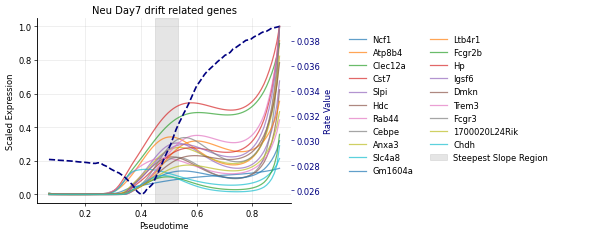

In [327]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_genes_list = sig_genes.index.to_list()
sig_gene_expr = Neu_expr_df.loc[:,sig_genes_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_Day7, 
    lineage='Neu', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_genes_list)//10, frameon=False)
ax1.set_title("Neu Day7 drift related genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Neu_Day7_DEGenes.pdf")

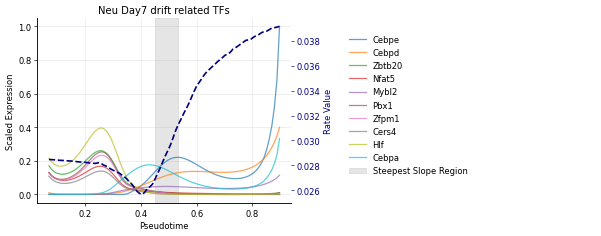

In [331]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = sig_TFs.index.to_list()
sig_gene_expr = Neu_expr_df.loc[:,sig_TFs_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_Day7, 
    lineage='Neu', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Neu Day7 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Neu_Day7_DETFs.pdf")

# Meg Day 161

In [77]:
cell_time

array([0.38165402, 0.33401798, 0.30713654, ..., 0.3581964 , 0.33913127,
       0.33635838])

In [49]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Meg')
gam_fit = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)

Meg_expr_df = prepare_expression_data(gam_fit, pseudotime=x_project['Meg'])
Meg_expr_df.to_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index=True)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [175]:
Meg_expr_df = prepare_expression_data(gam_fit, pseudotime=x_project['Meg'][8:])
# Meg_expr_df.to_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index=True)

In [176]:
Meg_expr_df.shape

(91, 11655)

In [169]:
lineage = 'Meg'
day = 161

for day_id in [0,1]:

    day = adata_raw.uns['pop']['t'][day_id]

    steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
    pseudotime_range = (steepest_region[lineage]['start_bin'], 
                    steepest_region[lineage]['end_bin'])
    pseudotime_range = (0.27,0.4)
    # # Run association tests

    print(f"Running association test for {lineage} lineage...")
    test = de_test.AssociationTest(gam_fit, ['lineage'])
    result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
    result_lin_day['gene_symbol'] = gam_fit['gene_symbol']
    result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

    # select significantly DE genes and annotate TF
    print(f"Selecting significantly DE genes for {lineage} lineage...")
    significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
    significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
    significant_genes.set_index("gene_symbol", inplace=True)

    # compute parameter derivative
    print(f"Selecting drift derivative related genes for {lineage} lineage...")
    dx = x_project[lineage][0]
    drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

    # compute correlation and mutual information
    corr_list = [pearsonr(Meg_expr_df[gene].values[10:-3], drift_derivatives[10:-3])[0] for gene in significant_genes.index]
    mi_list = [calculate_mutual_information(Meg_expr_df.loc[:,gene].values[10:-3], drift_derivatives[10:-3]) for gene in significant_genes.index]

    significant_genes['pearson_r'] = corr_list
    significant_genes['mutual_information'] = mi_list

    significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

Running association test for Meg lineage...


Selecting significantly DE genes for Meg lineage...
Selecting drift derivative related genes for Meg lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


Running association test for Meg lineage...
Selecting significantly DE genes for Meg lineage...
Selecting drift derivative related genes for Meg lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


<Axes: >

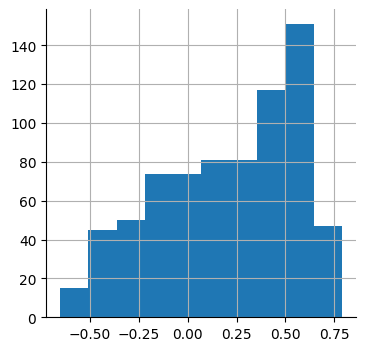

In [98]:
significant_genes['pearson_r'].hist()

In [170]:
Meg_sig_genes = significant_genes.query("`meanLogFC`>2 & `fdr` <1e-3 & `pearson_r` > 0.1 & `mutual_information`>0.4" ).sort_values(["mutual_information"], ascending=False)
print(Meg_sig_genes.shape)

Meg_sig_genes

(21, 9)


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Mdm1,11309,26.000328,1.0,3.413594e-07,2.305260,1.849840e-05,False,0.174758,0.835333
P2ry1,3925,24.245354,1.0,8.481142e-07,2.179082,3.969788e-05,False,0.311399,0.831411
Endod1,13516,20.243982,1.0,6.816757e-06,3.259912,2.378721e-04,False,0.168318,0.800550
Robo3,13717,19.187127,1.0,1.185099e-05,2.446345,3.826130e-04,False,0.271714,0.797791
Tuba8,8347,46.836707,1.0,7.715466e-12,2.148527,1.362481e-09,False,0.342435,0.786981
Rgs10,10165,78.034438,1.0,1.012597e-18,2.935971,4.371042e-16,False,0.185219,0.779231
Ache,7154,30.999699,1.0,2.580685e-08,2.828549,1.879867e-06,False,0.203187,0.763939
Gucy1b1,4003,22.658690,1.0,1.934832e-06,3.205779,8.260242e-05,False,0.190280,0.743929
Samd14,15768,39.076242,1.0,4.075736e-10,3.236314,4.948199e-08,False,0.208878,0.743155


In [144]:
Meg_sig_TFs = significant_genes.query("`meanLogFC`>1 & `pearson_r` > 0 & `mutual_information`>0.3 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
print(Meg_sig_TFs.shape)

(13, 9)


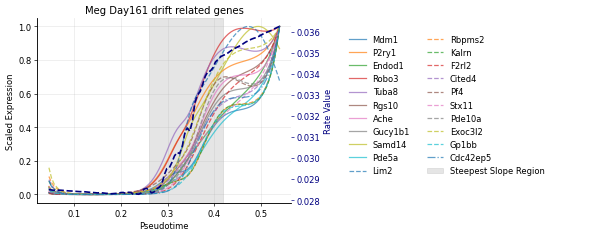

In [178]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_genes_list = Meg_sig_genes.index.to_list()
sig_gene_expr = Meg_expr_df.loc[:,sig_genes_list]#.iloc[10:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_genes_list)//10), frameon=False)
ax1.set_title("Meg Day161 drift related genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day161_DEgenes.pdf")

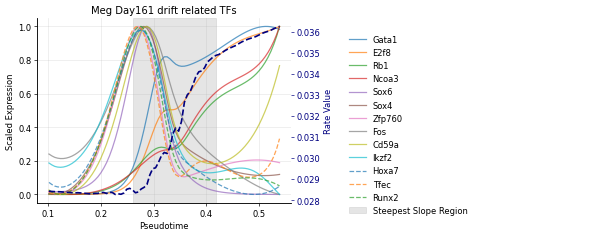

In [181]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Meg_sig_TFs.index.to_list()
sig_gene_expr = Meg_expr_df.loc[:,sig_TFs_list].iloc[10:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Meg Day161 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day161_DETFs.pdf")

# Ery

In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Ery')
gam_fit_Ery = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
GAMfit_dict['Ery'] = gam_fit_Ery.copy()

# Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'][8:])
# Ery_expr_df.to_csv("results/tompos_Ery_GAM/GAM_scaled_expression.csv", index=True)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Ery')
gam_fit_Ery = de_test.run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
GAMfit_dict['Ery'] = gam_fit_Ery.copy()

Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'])
# Ery_expr_df.to_csv("results/tompos_Ery_GAM/GAM_scaled_expression.csv", index=True)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [242]:
Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'])

In [241]:
cell_time.min(), cell_time.max()

(0.13948978097419001, 0.8806194861629267)

In [224]:
pseudotime_range

(0.16273311392683998, 0.43240513129131775)

In [226]:
pseudotime_range = (steepest_region[lineage]['start_bin'], 
                    steepest_region[lineage]['end_bin'])

In [227]:
pseudotime_range

(0.12008447538585365, 0.378043718807317)

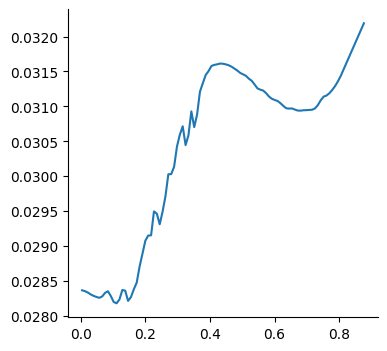

In [257]:
plt.plot(x_project['Ery'], v_project['Ery'][1])

In [258]:
lineage = 'Ery'

for day_id in [0,1,7]:

    day = adata_raw.uns['pop']['t'][day_id]

    steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
    pseudotime_range = (0.2, 
                    steepest_region[lineage]['end_bin'])
    # # Run association tests

    print(f"Running association test for {lineage} lineage...")
    test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
    result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
    result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']
    result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

    # select significantly DE genes and annotate TF
    print(f"Selecting significantly DE genes for {lineage} lineage...")
    significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
    significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
    significant_genes.set_index("gene_symbol", inplace=True)

    # compute parameter derivative
    print(f"Selecting drift derivative related genes for {lineage} lineage...")
    dx = x_project[lineage][0]
    drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

    # compute correlation and mutual information
    corr_list = [pearsonr(Ery_expr_df[gene].values[:-3], drift_derivatives[8:-3])[0] for gene in significant_genes.index]
    mi_list = [calculate_mutual_information(Ery_expr_df.loc[:,gene].values[:-3], drift_derivatives[8:-3]) for gene in significant_genes.index]

    significant_genes['pearson_r'] = corr_list
    significant_genes['mutual_information'] = mi_list

    significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

Running association test for Ery lineage...
Selecting significantly DE genes for Ery lineage...
Selecting drift derivative related genes for Ery lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


ValueError: x and y must have the same length.

In [253]:
print(f"Running association test for {lineage} lineage...")
test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']
# result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

Running association test for Ery lineage...
Error processing gene 4: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 5: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 7: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 10: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 12: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 13: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 16: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene

In [229]:
Ery_sig_gene_df = significant_genes
print(Ery_sig_gene_df.shape)
Ery_sig_gene_df.head()

(0, 9)


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,


array([[<Axes: title={'center': 'pearson_r'}>,
        <Axes: title={'center': 'mutual_information'}>]], dtype=object)

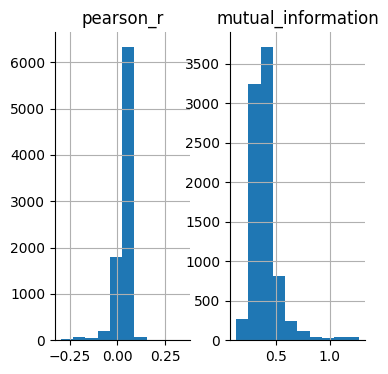

In [197]:
Ery_sig_gene_df[['pearson_r','mutual_information']].hist()

In [201]:
Ery_sig_TFs = Ery_sig_gene_df.query("`pearson_r` > 0.05 & `mutual_information`>0.4 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
print(Ery_sig_TFs.shape)

(14, 9)


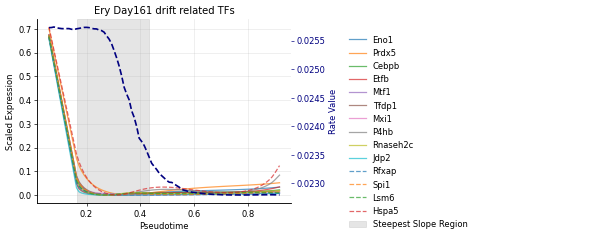

In [212]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Ery_sig_TFs.index.to_list()
sig_gene_expr = Ery_expr_df.loc[:,sig_TFs_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Ery', 
    day_idx=8,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Ery Day161 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Ery_Day161_DETFs.pdf")